In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- Experiment 1: Correct constraints vs. no constraints vs. wrong constraints ---

def make_constraints(feature_names, constraint_dict):
    """Build monotonic_cst array from a dict of {feature_name: direction}."""
    constraints = [0] * len(feature_names)
    for feat, direction in constraint_dict.items():
        idx = list(feature_names).index(feat)
        constraints[idx] = direction
    return constraints

# Correct constraints
correct = make_constraints(data.feature_names, {
    'mean radius': -1,
    'worst radius': -1,
    'mean concave points': -1,
    'worst concave points': -1,
})

# WRONG constraints
wrong = make_constraints(data.feature_names, {
    'mean radius': 1,    # WRONG
    'worst radius': 1,   # WRONG
    'mean concave points': 1,   # WRONG
    'worst concave points': 1,  # WRONG
})

# Partially wrong: some correct, some wrong
mixed = make_constraints(data.feature_names, {
    'mean radius': -1,         # correct
    'worst radius': -1,        # correct
    'mean concave points': 1,  # WRONG
    'worst concave points': 1, # WRONG
})

results = {}
for name, cst in [("No constraints", None), ("Correct", correct), 
                   ("All wrong", wrong), ("Mixed", mixed)]:
    model = HistGradientBoostingClassifier(
        monotonic_cst=cst, max_iter=200, random_state=42
    )
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    test_recall = recall_score(y_test, model.predict(X_test), pos_label=0)  # recall for malignant
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_acc,
        'malignant_recall': test_recall
    }
    print(f"{name:20s}  CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f}  "
          f"Test: {test_acc:.3f}  Malignant Recall: {test_recall:.3f}")

No constraints        CV: 0.963±0.019  Test: 0.974  Malignant Recall: 0.953
Correct               CV: 0.963±0.019  Test: 0.974  Malignant Recall: 0.953
All wrong             CV: 0.965±0.027  Test: 0.974  Malignant Recall: 0.953
Mixed                 CV: 0.965±0.025  Test: 0.974  Malignant Recall: 0.953


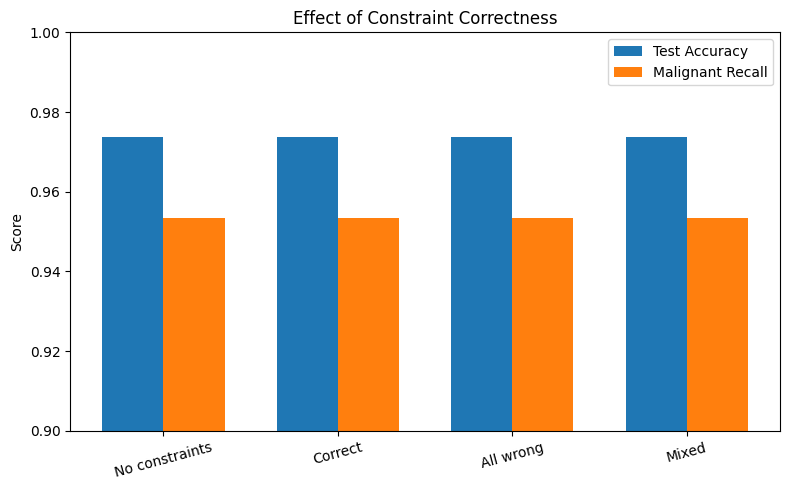

In [6]:
import matplotlib.pyplot as plt
import numpy as np

names = list(results.keys())
test_accs = [results[n]['test_accuracy'] for n in names]
recalls = [results[n]['malignant_recall'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, test_accs, width, label='Test Accuracy')
ax.bar(x + width/2, recalls, width, label='Malignant Recall')
ax.set_ylabel('Score')
ax.set_title('Effect of Constraint Correctness')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.legend()
ax.set_ylim(0.90, 1.0)  # zoom in to see differences
plt.tight_layout()
plt.savefig('constraint_comparison.png', dpi=150)
plt.show()

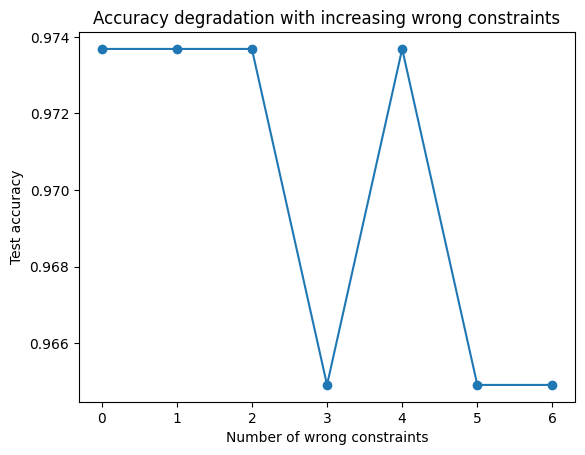

In [7]:
# --- Experiment 2: How many wrong constraints can you tolerate? ---
# Gradually add wrong constraints one at a time and track degradation

feature_to_corrupt = ['mean radius', 'worst radius', 'mean concave points', 
                      'worst concave points', 'mean area', 'worst area']

degradation = []
for n_wrong in range(len(feature_to_corrupt) + 1):
    cst_dict = {}
    for i, feat in enumerate(feature_to_corrupt):
        if i < n_wrong:
            cst_dict[feat] = 1   # wrong direction
        else:
            cst_dict[feat] = -1  # correct direction
    
    cst = make_constraints(data.feature_names, cst_dict)
    model = HistGradientBoostingClassifier(monotonic_cst=cst, max_iter=200, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    degradation.append({'n_wrong': n_wrong, 'accuracy': acc})

deg_df = pd.DataFrame(degradation)
plt.plot(deg_df['n_wrong'], deg_df['accuracy'], marker='o')
plt.xlabel('Number of wrong constraints')
plt.ylabel('Test accuracy')
plt.title('Accuracy degradation with increasing wrong constraints')
plt.savefig('wrong_constraint_degradation.png', dpi=150)